# DeiT-Small — Pipeline Walkthrough (demo run)

Interactive walkthrough of the training pipeline in
[`retinopathy-classification-pipeline`](../retinopathy-classification-pipeline) — same
`common.py`/`train.py` code that runs for real on RunPod, just pointed at a
**small subset** of the data and **fewer epochs** so it finishes in a few
minutes here instead of needing a GPU.

For the actual full-data fine-tuning run (used for the paper's results), use:
```bash
python train.py --config configs/deit_small.yaml
```
which trains on the full split for the epoch counts in the config, and logs
everything to MLflow (Databricks-hosted).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader

PIPELINE_DIR = Path("../retinopathy-classification-pipeline").resolve()
sys.path.insert(0, str(PIPELINE_DIR))

from common import (  # noqa: E402
    RetinaDataset,
    build_model,
    build_transforms,
    get_device,
    set_backbone_trainable,
    set_seed,
)
from train import run_epoch  # noqa: E402  (reuse the exact same train/eval loop as the real script)

MODEL_NAME = "deit_small_patch16_224"
set_seed(42)
device = get_device()
print(f"model: {MODEL_NAME}")
print(f"device: {device}")

/Users/tiarasabrina/Documents/PROJECT/AI/research-retinopathy-disease-classification/retinopathy-classification-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model: deit_small_patch16_224
device: mps


## 1. Data

Same stratified split every model uses (`dataset_splits/`, built once by `make_splits.py`).

In [2]:
class_names = __import__("json").loads((PIPELINE_DIR / "dataset_splits" / "class_names.json").read_text())
train_df = pd.read_csv(PIPELINE_DIR / "dataset_splits" / "train.csv")
val_df = pd.read_csv(PIPELINE_DIR / "dataset_splits" / "val.csv")
test_df = pd.read_csv(PIPELINE_DIR / "dataset_splits" / "test.csv")

print("classes:", class_names)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {len(df)} images -> {df['label'].value_counts().to_dict()}")

classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
train: 2951 images -> {'diabetic_retinopathy': 768, 'normal': 752, 'cataract': 726, 'glaucoma': 705}
val: 633 images -> {'diabetic_retinopathy': 165, 'normal': 161, 'cataract': 156, 'glaucoma': 151}
test: 633 images -> {'diabetic_retinopathy': 165, 'normal': 161, 'cataract': 156, 'glaucoma': 151}


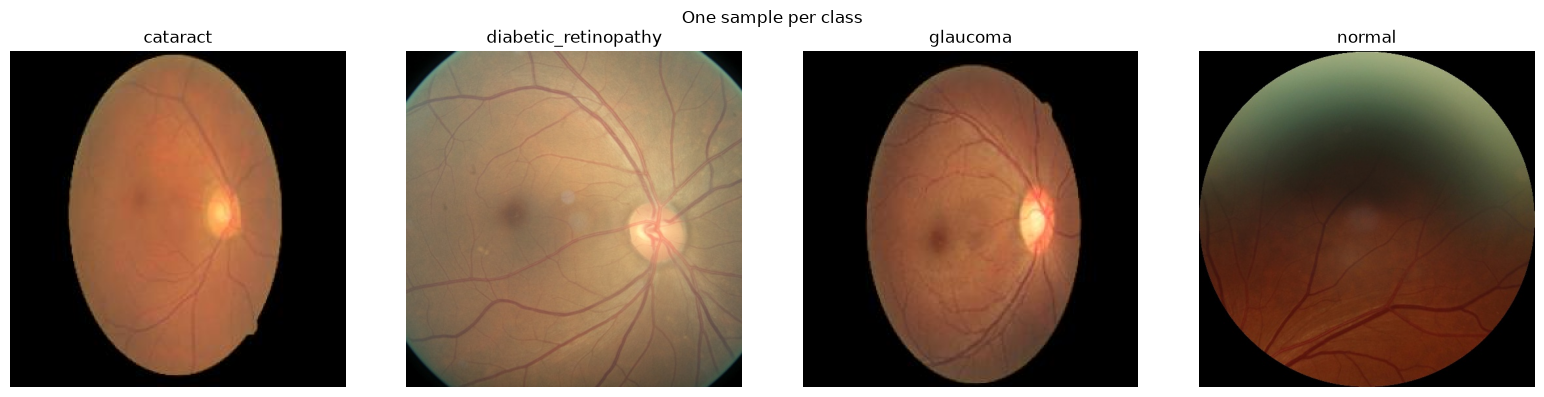

In [3]:
fig, axes = plt.subplots(1, len(class_names), figsize=(4 * len(class_names), 4))
for ax, cname in zip(axes, class_names):
    sample_path = PIPELINE_DIR / train_df[train_df["label"] == cname].iloc[0]["filepath"]
    ax.imshow(Image.open(sample_path).convert("RGB"))
    ax.set_title(cname)
    ax.axis("off")
fig.suptitle("One sample per class")
plt.tight_layout()
plt.show()

## 2. Model + preprocessing

`build_model` loads a timm pretrained checkpoint; `build_transforms` resolves the normalization stats that specific checkpoint expects.

In [4]:
model = build_model(MODEL_NAME, num_classes=len(class_names), pretrained=True).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME}: {n_params:,} parameters")

train_tf = build_transforms(model, image_size=224, is_train=True)
eval_tf = build_transforms(model, image_size=224, is_train=False)

deit_small_patch16_224: 21,667,204 parameters


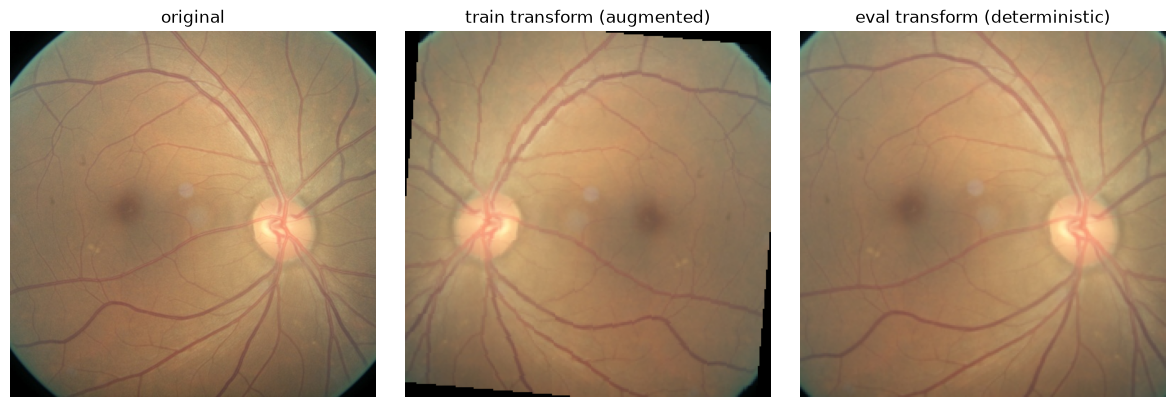

In [5]:
# Show what the training augmentation actually does to one image (denormalized for display).
sample_path = PIPELINE_DIR / train_df.iloc[0]["filepath"]
raw = Image.open(sample_path).convert("RGB")

def denorm(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw); axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(denorm(train_tf(raw))); axes[1].set_title("train transform (augmented)"); axes[1].axis("off")
axes[2].imshow(denorm(eval_tf(raw))); axes[2].set_title("eval transform (deterministic)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Freeze / unfreeze mechanics

Phase 1 (linear probe) trains only the classifier head; Phase 2 (fine-tune) trains everything.

In [6]:
set_backbone_trainable(model, trainable=False)
frozen_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"linear-probe phase: {frozen_trainable:,} / {n_params:,} params trainable")

set_backbone_trainable(model, trainable=True)
full_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"fine-tune phase:    {full_trainable:,} / {n_params:,} params trainable")

linear-probe phase: 1,540 / 21,667,204 params trainable
fine-tune phase:    21,667,204 / 21,667,204 params trainable


## 4. Demo training run

Subsampled on purpose (150 images/class train, 40/class val) with 2+2 epochs,
just to watch loss/F1 actually move within a few minutes on a laptop. The real
run (`train.py`) uses the full split and the epoch counts in
`configs/*.yaml`.

In [7]:
N_TRAIN_PER_CLASS = 150
N_VAL_PER_CLASS = 40
N_TEST_PER_CLASS = 40
LINEAR_PROBE_EPOCHS = 2
FINETUNE_EPOCHS = 2
BATCH_SIZE = 32

demo_train_df = train_df.groupby("label", group_keys=False).head(N_TRAIN_PER_CLASS)
demo_val_df = val_df.groupby("label", group_keys=False).head(N_VAL_PER_CLASS)
demo_test_df = test_df.groupby("label", group_keys=False).head(N_TEST_PER_CLASS)

demo_train_csv = PIPELINE_DIR / "dataset_splits" / "_demo_train.csv"
demo_val_csv = PIPELINE_DIR / "dataset_splits" / "_demo_val.csv"
demo_test_csv = PIPELINE_DIR / "dataset_splits" / "_demo_test.csv"
demo_train_df.to_csv(demo_train_csv, index=False)
demo_val_df.to_csv(demo_val_csv, index=False)
demo_test_df.to_csv(demo_test_csv, index=False)

train_loader = DataLoader(RetinaDataset(demo_train_csv, PIPELINE_DIR, train_tf), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(RetinaDataset(demo_val_csv, PIPELINE_DIR, eval_tf), batch_size=BATCH_SIZE)
test_loader = DataLoader(RetinaDataset(demo_test_csv, PIPELINE_DIR, eval_tf), batch_size=BATCH_SIZE)

print(f"demo train/val/test sizes: {len(demo_train_df)}/{len(demo_val_df)}/{len(demo_test_df)}")

demo train/val/test sizes: 600/160/160


In [8]:
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
history = []  # (phase, epoch, train_loss, train_f1, val_loss, val_f1)

# --- Phase 1: linear probe ---
set_backbone_trainable(model, trainable=False)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=0.05)
for epoch in range(LINEAR_PROBE_EPOCHS):
    train_loss, train_f1, _, _ = run_epoch(model, train_loader, device, criterion, optimizer)
    val_loss, val_f1, _, _ = run_epoch(model, val_loader, device, criterion)
    history.append(("linear_probe", epoch, train_loss, train_f1, val_loss, val_f1))
    print(f"[linear_probe] epoch {epoch}: train_loss={train_loss:.4f} train_f1={train_f1:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

  0%|          | 0/19 [00:00<?, ?it/s]

  5%|▌         | 1/19 [00:01<00:31,  1.76s/it]

 11%|█         | 2/19 [00:02<00:17,  1.05s/it]

 16%|█▌        | 3/19 [00:02<00:13,  1.22it/s]

 21%|██        | 4/19 [00:03<00:10,  1.48it/s]

...

 40%|████      | 2/5 [00:00<00:00,  3.82it/s]

 60%|██████    | 3/5 [00:00<00:00,  3.26it/s]

 80%|████████  | 4/5 [00:01<00:00,  3.45it/s]

100%|██████████| 5/5 [00:01<00:00,  2.67it/s]

[linear_probe] epoch 1: train_loss=0.8829 train_f1=0.7085 val_loss=0.8598 val_f1=0.6134


In [9]:
# --- Phase 2: full fine-tune ---
set_backbone_trainable(model, trainable=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)
for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_f1, _, _ = run_epoch(model, train_loader, device, criterion, optimizer)
    val_loss, val_f1, _, _ = run_epoch(model, val_loader, device, criterion)
    scheduler.step()
    history.append(("finetune", epoch, train_loss, train_f1, val_loss, val_f1))
    print(f"[finetune] epoch {epoch}: train_loss={train_loss:.4f} train_f1={train_f1:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

  0%|          | 0/19 [00:00<?, ?it/s]

  5%|▌         | 1/19 [00:01<00:27,  1.55s/it]

 11%|█         | 2/19 [00:03<00:26,  1.54s/it]

 16%|█▌        | 3/19 [00:04<00:20,  1.31s/it]

 21%|██        | 4/19 [00:05<00:17,  1.19s/it]

...

 40%|████      | 2/5 [00:00<00:00,  3.36it/s]

 60%|██████    | 3/5 [00:00<00:00,  2.97it/s]

 80%|████████  | 4/5 [00:01<00:00,  3.18it/s]

100%|██████████| 5/5 [00:01<00:00,  2.47it/s]

[finetune] epoch 1: train_loss=0.6166 train_f1=0.8840 val_loss=0.6942 val_f1=0.8101


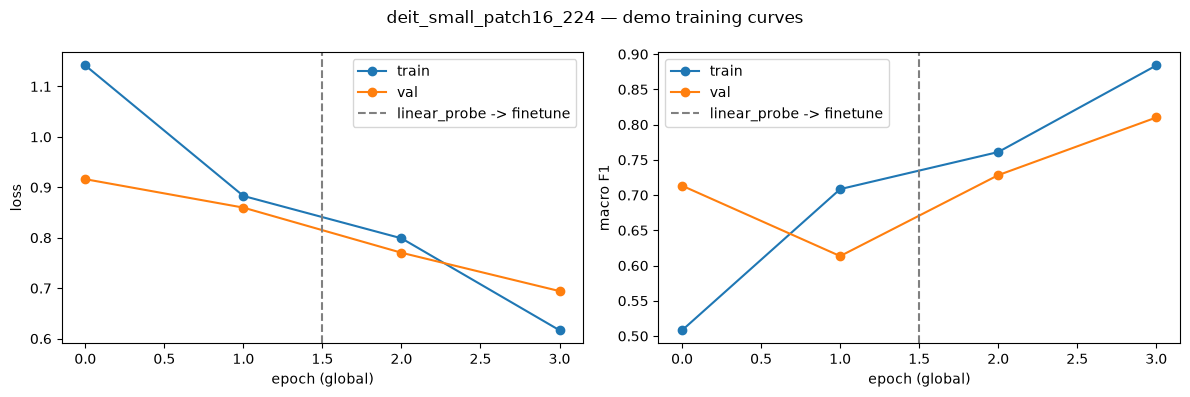

In [10]:
hist_df = pd.DataFrame(history, columns=["phase", "epoch", "train_loss", "train_f1", "val_loss", "val_f1"])
hist_df["global_step"] = range(len(hist_df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, ylabel in [(axes[0], "loss", "loss"), (axes[1], "f1", "macro F1")]:
    ax.plot(hist_df["global_step"], hist_df[f"train_{metric}"], marker="o", label="train")
    ax.plot(hist_df["global_step"], hist_df[f"val_{metric}"], marker="o", label="val")
    phase_boundary = (hist_df["phase"] == "finetune").idxmax() - 0.5
    ax.axvline(phase_boundary, color="gray", linestyle="--", label="linear_probe -> finetune")
    ax.set_xlabel("epoch (global)"); ax.set_ylabel(ylabel); ax.legend()
fig.suptitle(f"{MODEL_NAME} — demo training curves")
plt.tight_layout()
plt.show()

## 5. Test evaluation

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:00<00:00,  4.13it/s]

 40%|████      | 2/5 [00:00<00:01,  2.82it/s]

 60%|██████    | 3/5 [00:00<00:00,  3.26it/s]

 80%|████████  | 4/5 [00:01<00:00,  2.58it/s]

100%|██████████| 5/5 [00:02<00:00,  2.19it/s]

test_loss=0.6580 test_macro_f1=0.8304

                      precision    recall  f1-score   support

            cataract       0.86      0.95      0.90        40
diabetic_retinopathy       0.92      0.85      0.88        40
            glaucoma       0.82      0.82      0.82        40
              normal       0.72      0.70      0.71        40

            accuracy                           0.83       160
           macro avg       0.83      0.83      0.83       160
        weighted avg       0.83      0.83      0.83       160



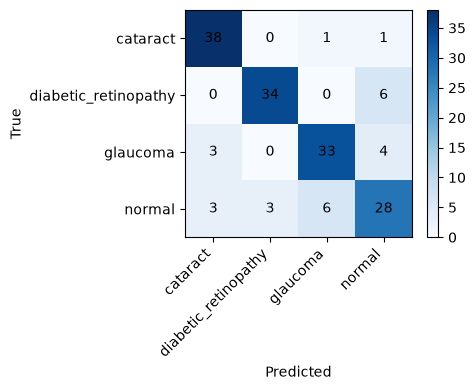

In [11]:
test_loss, test_f1, y_true, y_pred = run_epoch(model, test_loader, device, criterion)
print(f"test_loss={test_loss:.4f} test_macro_f1={test_f1:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Notes

- These numbers are **not** meaningful model-quality results — 150 images/class
  and 2+2 epochs is only enough to confirm the pipeline (data → model → train
  loop → eval) actually works end to end.
- The real comparison (DeiT-Small vs. the other architecture) comes from
  `train.py --config configs/*.yaml` run on RunPod with the full split and
  full epoch budget, tracked in MLflow.
